This problem set/assignment will require you to create simple quantum algorithms and implement them in QISKIT so that we can autograde your work. We have presented QISKIT in our notes and provided many examples of how to express quantum circuits in QISKIT. You may find documentation of QISKIT from the IBM website: https://docs.quantum.ibm.com/

<h2>Problem 1</h2>

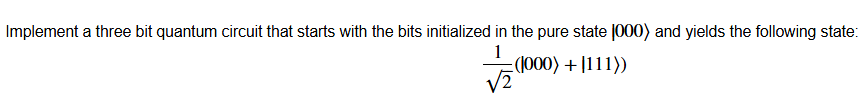
<h4>strategy</h4>

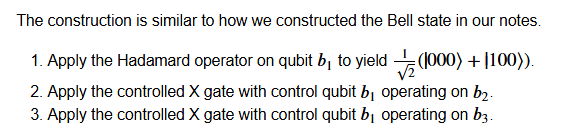

In [15]:


try:
    import qiskit_aer
except:
    !pip3 install qiskit_aer
    import qiskit_aer


try:
    import qiskit.visualization
except:
    !pip3 install 'qiskit[visualization]'
    import qiskit.visualization

try:
    import qiskit.circuit.library
except:
    !pip3 install qiskit.circuit.library
    import qiskit.circuit.library


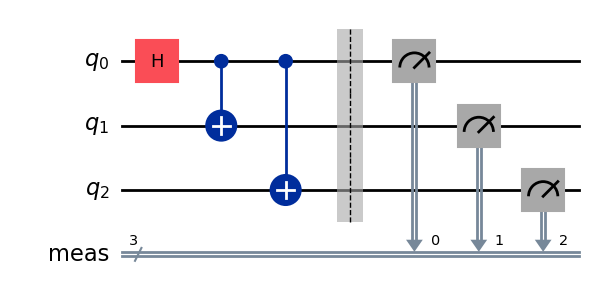

In [1]:
from qiskit import QuantumCircuit

def create_ghz_circuit(qc):
    # please implement your circuit here.
    # useful tutorials
    #  https://docs.quantum.ibm.com/build/circuit-construction
    # your code here
    qc.h(0)  # apply hadamard on qubit # 0
    qc.cx(0, 1) # apply control-X with 0 as the control bit and 1 as the bit being operated on
    qc.cx(0, 2) # apply control-X with 0 as the control bit and 2 as the bit being operated on
    
qc = QuantumCircuit(3) # create a quantum circuit with three qubits
create_ghz_circuit(qc) # call the code created by the student to populate the gates in the circuit
qc.measure_all() # measure the outputs
qc.draw('mpl', style="iqp") # draw the circuit

Result counts from 1024 simulations: {'111': 523, '000': 501}


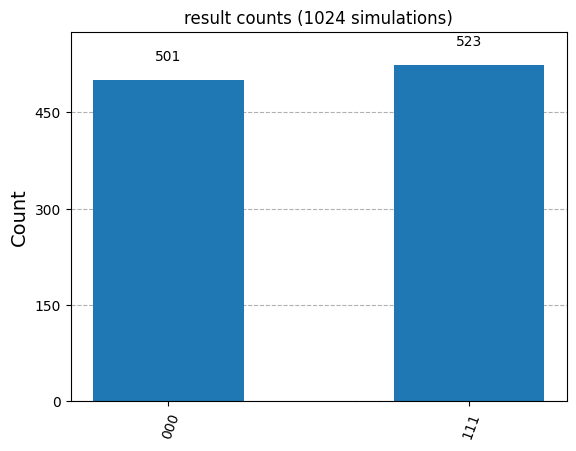

In [5]:
from qiskit import transpile 
from qiskit_aer import Aer

from qiskit.visualization import plot_histogram
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc, simulator) 

# Run and get counts
result = simulator.run(qc).result()
counts = result.get_counts(circ)
print(f'Result counts from 1024 simulations: {counts}')
assert counts['000'] >= 450 and counts['111'] >= 450, 'counts of 000 and 111 state are not roughly equal'
assert ('001' not in counts), 'qubit 001 part of superposition which should not be the case'
assert ('011' not in counts), 'qubit 011 part of superposition which should not be the case'
assert ('010' not in counts), 'qubit 010 part of superposition which should not be the case'
assert ('100' not in counts), 'qubit 100 part of superposition which should not be the case'
assert ('101' not in counts), 'qubit 101 part of superposition which should not be the case'
assert ('110' not in counts), 'qubit 110 part of superposition which should not be the case'
plot_histogram(counts, title='result counts (1024 simulations)')


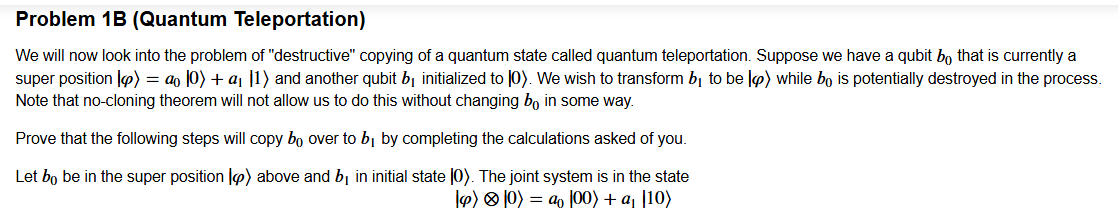
1. Apply the Hadamard gate to b1. What is the resulting state?
<br/>
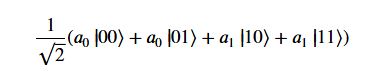
<br/>
2.Apply the controlled-X gate to qubit  𝑏0  with control qubit  𝑏1. What is the resulting state?
<br />

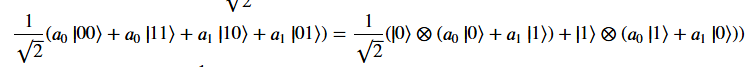
<br />
3. Apply the controlled-X gate to qubit  𝑏1  with control qubit  𝑏0. What is the resulting state?
<br />
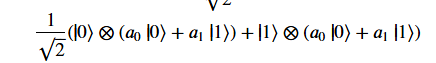
<br />

4. Measure the qubit  𝑏0. Write down the possible results of the measurement along with the probabilities and the states for  𝑏1
  after the partial measurement.
  <br />
  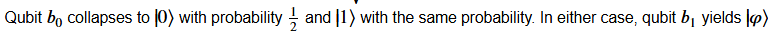

  If you followed along the steps above, you will realize that the quantum circuit will cause  𝑏0  to collapse to either a |0⟩ or a |1⟩   but  𝑏1   will now have  |𝜑⟩. This is the essence of quantum teleportation. It is important that you do the calculations correctly and obtain the result before you try the problem below.

5. Implement the function quantum_teleport that takes in an instance of QuantumCircuit and index of two qubits b0 and b1. It should implement the above scheme to copy b0 into b1, which is initialized to  |0⟩. Do not measure b1.


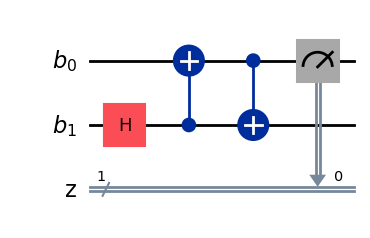

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
def quantum_teleport(qc, b0, b1, cbit): 
    # qc is a quantum circuit instance 
    # b0 and b1 are indices of two bits. 
    # cbit is a classical bit that you will need for the partial mmeasurement at step 4.
    # assume b0 != b1
    # implement the circuit to "teleport" the state of q1 to q2.
    qc.h(b1) # hadamard gate on b1
    qc.cx(b1, b0) # apply control-X to 1 as the control bit and 0 as the bit being operated on
    qc.cx(b0, b1) # apply control-X to 0 as the control bit and 1 as the bit being operated on
    qc.measure(b0, cbit)
    # no need to return anything: you will be mutating the circuit qc.
    
b = QuantumRegister(2, 'b')
c = ClassicalRegister(1,'z')
qc = QuantumCircuit(b, c)
quantum_teleport(qc, b[0], b[1], c[0])
qc.draw('mpl', style='iqp')

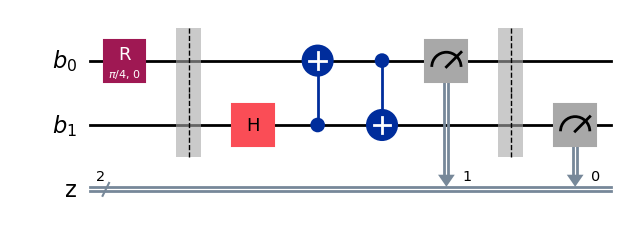

Result counts from 1024 simulations: {'10': 461, '00': 424, '01': 73, '11': 66}
 b0 = |0> count is 497 and b0=|1> count is 527 : must be roughly equal
 b1 = |0> count is 885 and b1=|1> count is 139 :expected  b1 = |1> happens roughly 17% of the time, and b1=|0> 83% 
Test passed


In [11]:
# Test 1. We will create a single qubit circuit and copy it over.
# 
from numpy import pi
from qiskit import transpile 
from qiskit_aer import Aer

b = QuantumRegister(2, 'b')
c = ClassicalRegister(2,'z')
qc_test1 = QuantumCircuit(b, c)

qc_test1.r(2*pi/8, 0.0, b[0]) # apply a pi/8 rotation
# b[0] should be prepared in state 
# cos(pi/8) |0> - sin(pi/8) |1>
qc_test1.barrier()
# Teleport b[0] to b[1]
quantum_teleport(qc_test1, b[0], b[1], c[1]) # teleport 
qc_test1.barrier()
qc_test1.measure(b[1], c[0]) # measure
display(qc_test1.draw('mpl', style='iqp'))
# test 
from qiskit.visualization import plot_histogram
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc_test1, simulator) 

# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
print(f'Result counts from 1024 simulations: {counts}')
# collect the counts
# roughly we should get measurement of b[0] = 0, b[0] = 1 with 50% probability
# probability of b[1] = 0 and b[1] = 1 must be in the ratio tan^2(pi/8) ~ 0.17157

b0_0_count = counts['00'] + counts['01']
b0_1_count = counts['10'] + counts['11']
print(f' b0 = |0> count is {b0_0_count} and b0=|1> count is {b0_1_count} : must be roughly equal')
assert b0_0_count >= 0.85 * 512 and b0_0_count <= 1.15 * 512

b1_0_count = counts['00'] + counts['10']
b1_1_count = counts['01'] + counts['11']

print(f' b1 = |0> count is {b1_0_count} and b1=|1> count is {b1_1_count} :expected  b1 = |1> happens roughly 17% of the time, and b1=|0> 83% ')
assert b1_0_count >= 0.7 * 1024 and b1_0_count <= 0.95 * 1024

print('Test passed')


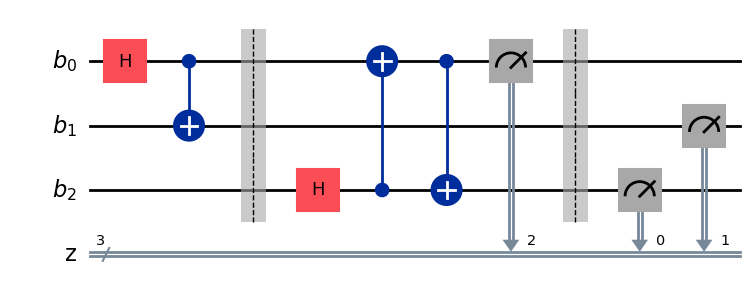

Result counts from 1024 simulations: {'000': 241, '100': 249, '111': 268, '011': 266}
Test passed


In [12]:
# Test 1. We will create a single qubit circuit and copy it over.
# 
from numpy import pi
from qiskit import transpile
from qiskit_aer import Aer

b = QuantumRegister(3, 'b')
c = ClassicalRegister(3,'z')
qc_test2 = QuantumCircuit(b, c)
# create the bell state for b[0] and b[1]
qc_test2.h(b[0])
qc_test2.cx(0, 1)
qc_test2.barrier()
# Teleport b[0] to b[2]
quantum_teleport(qc_test2, b[0], b[2], c[2]) # teleport b0 into b2
qc_test2.barrier()
qc_test2.measure(b[2], c[0]) # measure
qc_test2.measure(b[1], c[1]) # measure
display(qc_test2.draw('mpl', style='iqp'))
# test 
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc_test2, simulator) 

# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
print(f'Result counts from 1024 simulations: {counts}')
# there should be no count for states of the form `*01` and `*10`
assert('001' not in counts)
assert('010' not in counts)
assert('101' not in counts)
assert('110' not in counts)
assert(0.2 * 1024 <= counts['000'] <= 0.3 * 1024)
assert(0.2 * 1024 <= counts['011'] <= 0.3 * 1024)
assert(0.2 * 1024 <= counts['100'] <= 0.3 * 1024)
assert(0.2 * 1024 <= counts['111'] <= 0.3 * 1024)

print('Test passed')


<h3>Problem 3 (Alice, Bob and Bell's Inequality)</h3>
In this problem, we will implement the protocol between Alice and Bob that was described in the video lecture on Bell's inequality. We would like you to examine that lecture video before attempting it.
<ul>
<li>Alice and Bob are each given a classical bit and a qubit  𝑏1,𝑞1 for Alice and  𝑏2,𝑞2 are Bob.</li>
<li>The classical bits are each the result of the toss of a fair coin. But these are not yet revealed to Alice/Bob.</li>
<li>


</li>
<li> At a given moment in time, each of them gets to know their own bits.</li>
<li> They need to respond back with answers in the form of classical bits  𝑧1,𝑧2 </li>
<li>


</li>
</ul>
<br />
The best they can do without the aid of qubits is a winning probability of  0.75 that can be obtained by simply each responding with a  0
  (the only way they lose is if  𝑏1=𝑏2=1 which is assumed to happen with  1/4 probability).
We showed a protocol in the video that allows them to beat the classical probability limit. Your goal is to implement that as part of a quantum circuit.

Implement the function alice_response(qcircuit, b1, qbit, cbit) that inputs a the coin toss result for alice b1, Alice's qubit qbit (entangled with Bob's but that does not matter here) and a classical bit to measure into. There is no need to return any results: we will take care of that in the testing code where we will read the classical bit as cbit as Alice's response.

Implement similarly the function bob_response(qcircuit, b2, qbit, cbit) for Bob.

Note: you can use the quantum rotation gate ry(2*theta,  qbit) to implement a theta degree rotation on a qubit. 

<ul>
<li>
<a href="https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.RYGate">https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.RYGate</a>
</li>
<li>
<a href="https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#ry">https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#ry</a>
</li>
</ul>



In [44]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from numpy import pi

def alice_response(qc, b1, qbit, cbit):
    # your code here
    print( f'b1=${b1}')
    if b1 == 1:
        qc.ry(pi/8, qbit)
        qc.measure(qbit, cbit)
    else:
        qc.measure(qbit, cbit)

def bob_response(qc, b2, qbit, cbit ):
    # your code here
    if b2 == 1:
        qc.ry(-pi/8, qbit)
        qc.measure(qbit, cbit)
    else:
        qc.measure(qbit, cbit)
    
        


Circuit for b1 = True and b2 = True
b1=$True


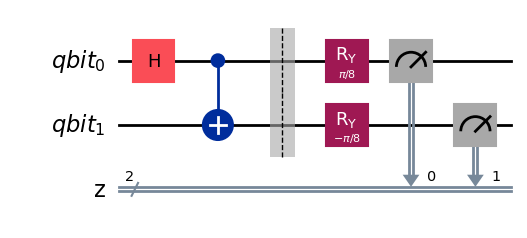

{'11': 428, '00': 435, '01': 75, '10': 86}
Circuit for b1 = True and b2 = False
b1=$True


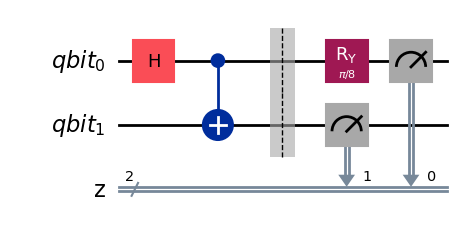

{'00': 492, '11': 495, '01': 20, '10': 17}
Circuit for b1 = False and b2 = True
b1=$False


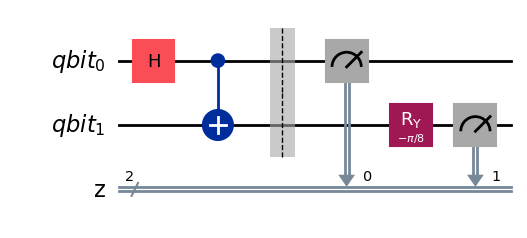

{'00': 506, '01': 22, '11': 477, '10': 19}
Circuit for b1 = False and b2 = False
b1=$False


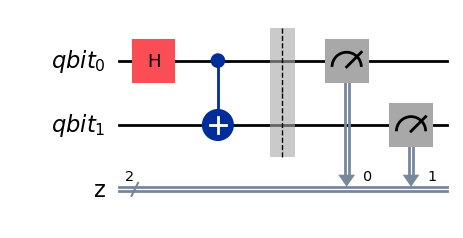

{'11': 509, '00': 515}
Probability of Alice/Bob Winning is estimated to be: 0.770263671875


In [45]:
from qiskit import transpile,  QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import Aer

def create_and_run_circuit(b1, b2):
    # let's collect the counts for b1 = 1, b2 = 1
    qbits11 = QuantumRegister(2, 'qbit')
    cbits11 = ClassicalRegister(2, 'z')
    # create the bell state
    print(f'Circuit for b1 = {b1} and b2 = {b2}')
    qc_11 = QuantumCircuit(qbits11, cbits11)
    qc_11.h(qbits11[0])
    qc_11.cx(qbits11[0], qbits11[1])
    qc_11.barrier()
    alice_response(qc_11, b1, qbits11[0], cbits11[0])
    bob_response(qc_11, b2, qbits11[1], cbits11[1] )
    display(qc_11.draw('mpl', style='iqp'))
    # simulate 
    
    # test 
    simulator = Aer.get_backend('aer_simulator')
    circ11 = transpile(qc_11, simulator) 
    # Run and get counts
    result = simulator.run(qc_11).result()
    counts = result.get_counts(circ11)
    print(counts)
    return counts 

success_count = 0
counts = create_and_run_circuit(True, True)
assert '01' in counts, 'Your result for b1 = True and b2 = True must have non-zero amplitude for |01>'
assert '10' in counts, 'Your result for b1 = True and b2 = True must have non-zero amplitude for |10>'
success_count += (counts['01'] + counts['10'])
counts = create_and_run_circuit(True, False)
assert '00' in counts, 'Your result for b1 = True and b2 = False must have non-zero amplitude for |01>'
assert '11' in counts, 'Your result for b1 = True and b2 = False must have non-zero amplitude for |10>'
success_count += (counts['00'] + counts['11'])
counts = create_and_run_circuit(False, True)
assert '00' in counts, 'Your result for b1 = False and b2 = True must have non-zero amplitude for |01>'
assert '11' in counts, 'Your result for b1 = False and b2 = True must have non-zero amplitude for |10>'
success_count += (counts['00'] + counts['11'])
counts = create_and_run_circuit(False, False)
assert '00' in counts, 'Your result for b1 = False and b2 = False must have non-zero amplitude for |01>'
assert '11' in counts, 'Your result for b1 = False and b2 = False must have non-zero amplitude for |10>'
success_count += (counts['00'] + counts['11'])

print(f'Probability of Alice/Bob Winning is estimated to be: {success_count/(4*1024)}')




<h2>Grover Search Marking Circuit</h2>
Design a quantum circuit with  4 input bits  𝑏0,𝑏1,𝑏2,𝑏3 such that it "marks" the amplitudes corresponding to the states



by inverting their amplitudes, leaving all other states unchanged. In this problem, you are asked to achieve this without using ancillary qubits or a result bit.
Let us consider the simple problem of inverting the amplitude corresponding to  |1111⟩
  leaving all the others unchanged. Show that this can be performed using a "multi controlled phase gate" with a phase of  𝜋
  radians. Write down a brief description of how such a circuit would work. See documentation for such a gate: <a href="https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.MCPhaseGate">https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.MCPhaseGate</a>

  Solution
  <br>

  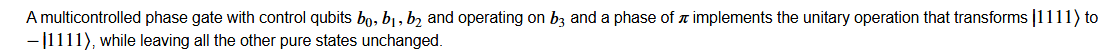
  
Using the idea of a multi-controlled phase gate, now use X-gates (quantum not) to convert each of the pure states  |0011⟩,|1100⟩,|0101⟩
  each to  |1111⟩  and use MCP gate above to mark the phase. Remember to use X-gates to convert the inputs back.

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit
from numpy import pi
def mark_pure_states(qc, b0 , b1, b2, b3):
    # mark the components corresponding to the pure states |0011> , |1100>, |0101>
    # your code here
    bits = [b0,b1,b2, b3]
    qc.mcp(pi, bits , )
    raise NotImplementedError
    
    
b = QuantumRegister(4, 'b')
qc = QuantumCircuit(b)
mark_pure_states(qc, b[0], b[1], b[2], b[3])
qc.draw('mpl', style='iqp')